# R2OMC on a 2-D Gaussian Noise Simulator

**Problem setup**

$$\theta \sim \mathrm{Uniform}(-3, 3)^2$$
$$y \mid \theta \sim \mathcal{N}(\theta,\, 0.1^2 \cdot I)$$
$$y_0 = (1.5,\, 1.5)$$

The true posterior is a tight Gaussian centred near $(1.5, 1.5)$.

This notebook covers:
1. Simple use — `fit` + `sample` + plot
2. Evaluation — C2ST and comparison with analytical ground truth
3. Verbose levels
4. Step-by-step R2OMC

In [1]:
import numpy as np
import jax

from lfi.priors import UniformPrior
from lfi.simulators import GaussianNoise
from lfi.inference.r2omc import R2OMC
from lfi.evaluation import c2st

# ── shared problem definition ──────────────────────────────────────────────────
DIM        = 2
SIGMA      = 0.1
OBS        = np.array([[1.5, 1.5]], dtype=np.float32)
BUDGET     = 500
NOF_SAMPLES = 200

prior = UniformPrior(dim=DIM, low=-3, high=3)
sim   = GaussianNoise(dim=DIM, dim_y=DIM, sigma_noise=SIGMA)

print(f"prior      : Uniform(-3, 3)^{DIM}")
print(f"simulator  : y = theta + N(0, {SIGMA}^2 I)")
print(f"observation: {OBS}")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


prior      : Uniform(-3, 3)^2
simulator  : y = theta + N(0, 0.1^2 I)
observation: [[1.5 1.5]]


---
## 1. Simple use

Create an `R2OMC` object, call `fit`, then `sample`.
All hyperparameters have sensible defaults — no tuning required for this problem.

In [2]:
method = R2OMC(prior, sim, OBS)
method.fit(budget=BUDGET)
samples = method.sample(nof_samples=NOF_SAMPLES)

Step 1: 2/2 informative dims
Step 2: 500×1 seeds optimised (4 epochs) | dist 0.0000 ± 0.0000
Step 3: 500/500 seeds inside prior
Step 4: 400 seeds accepted | eps_1=0.0000
Step 5: directions computed (hessian)
Step 6: 400×1 boxes built | eps_2=0.0033
Step 7: 200 samples returned


In [3]:
print(f"Posterior mean : {samples.mean(axis=0).round(3)}")
print(f"Posterior std  : {samples.std(axis=0).round(3)}")
print(f"True theta     : {OBS[0]}")

Posterior mean : [1.511 1.475]
Posterior std  : [0.11  0.109]
True theta     : [1.5 1.5]


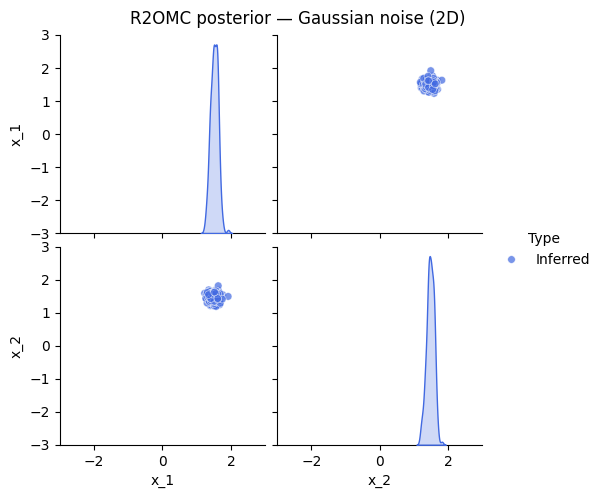

In [7]:
method.plot_posterior_samples(
    samples=samples,
    limits=[-3, 3],
    title="R2OMC posterior — Gaussian noise (2D)",
    show=True,
)

---
## 2. Evaluation

Compare R2OMC samples against the analytical posterior.
For this model the exact posterior is:
$$\theta \mid y_0 \approx \mathcal{N}(y_0,\, \sigma^2 I) \quad (\text{prior support is wide})$$

We use the **C2ST** (Classifier Two-Sample Test) to measure how close the
approximate posterior is to the ground truth:
- **0.5** = perfect (classifier cannot distinguish the two distributions)
- **1.0** = worst (distributions completely different)

In [8]:
# analytical ground truth samples
rng = np.random.default_rng(42)
gt_samples = rng.normal(loc=OBS[0], scale=SIGMA, size=(NOF_SAMPLES, DIM)).astype(np.float32)

score = c2st(gt_samples, samples)

print(f"Ground truth — mean: {gt_samples.mean(0).round(3)}  std: {gt_samples.std(0).round(3)}")
print(f"R2OMC        — mean: {samples.mean(0).round(3)}  std: {samples.std(0).round(3)}")
print(f"\nC2ST accuracy: {score:.3f}  (0.5 = perfect)")

Ground truth — mean: [1.502 1.497]  std: [0.099 0.091]
R2OMC        — mean: [1.511 1.475]  std: [0.11  0.109]

C2ST accuracy: 0.520  (0.5 = perfect)


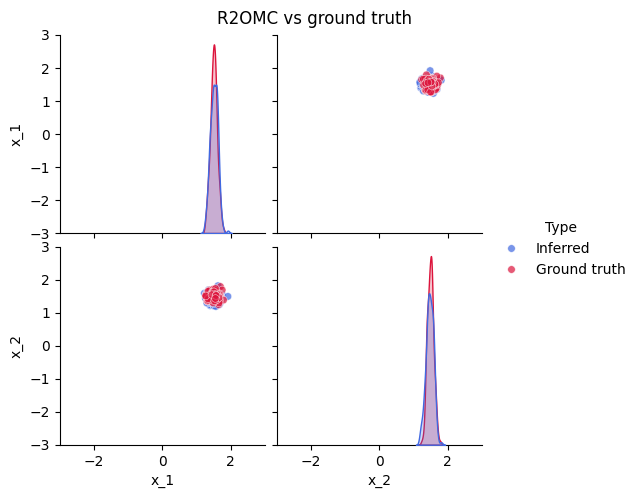

In [10]:
# overlay ground truth on the posterior plot
method.plot_posterior_samples(
    samples=samples,
    samples_gt=gt_samples,
    limits=[-3, 3],
    title="R2OMC vs ground truth",
    show=True,
)

---
## 3. Verbose levels

Both `fit` and `sample` accept a `verbose` argument:
- `verbose=0` — completely silent
- `verbose=1` — one summary line per step *(default)*
- `verbose=2` — detailed output: per-epoch stats, input/output blocks

In [11]:
for v in [0, 1, 2]:
    print(f"\n{'─'*50}")
    print(f"verbose={v}")
    print(f"{'─'*50}")
    m = R2OMC(prior, sim, OBS)
    m.fit(budget=BUDGET, verbose=v)
    _ = m.sample(nof_samples=NOF_SAMPLES, verbose=v)


──────────────────────────────────────────────────
verbose=0
──────────────────────────────────────────────────

──────────────────────────────────────────────────
verbose=1
──────────────────────────────────────────────────
Step 1: 2/2 informative dims
Step 2: 500×1 seeds optimised (4 epochs) | dist 0.0000 ± 0.0000
Step 3: 500/500 seeds inside prior
Step 4: 400 seeds accepted | eps_1=0.0000
Step 5: directions computed (hessian)
Step 6: 400×1 boxes built | eps_2=0.0033
Step 7: 200 samples returned

──────────────────────────────────────────────────
verbose=2
──────────────────────────────────────────────────
Step 1: find informative dimensions
-----------------------------------
Step 1: 2/2 informative dims

Step 2: Optimization (500x1)
---------------------------------
Epoch 1/4: 50 GD steps, alpha=0.1
  dist: 0.02404 ± 0.03757  [0.00000, 0.27129]
Epoch 2/4: 50 GD steps, alpha=0.1
  dist: 0.00005 ± 0.00008  [0.00000, 0.00047]
Epoch 3/4: 50 GD steps, alpha=0.1
  dist: 0.00001 ± 0.0000

---
## 4. Step-by-step R2OMC for full control

R2OMC runs 7 sequential steps.  
Each step can be called individually and the internal state inspected between calls.
This is useful for debugging, tuning, or understanding the algorithm.

| Step | Method | What it does |
|------|--------|--------------|
| 1 | `find_informative_dims` | Detect which simulator output dims carry information about θ |
| 2 | `sample_objective_functions` + `optimize` | For each CRN seed, find θ* = argmin d(θ, seed, y₀) |
| 3 | `filter_solutions_inside_prior` | Drop seeds whose θ* fell outside the prior support |
| 4 | `filter_solutions` | Keep the top fraction of seeds by d(θ*, seed, y₀) |
| 5 | `get_directions` | Compute local curvature (Hessian eigenvectors) at each θ* |
| 6 | `get_boxes` | Build an ellipsoidal bounding box around each θ* |
| 7 | `weighted_sampling` + `importance_resampling` | Sample inside the boxes and reweight |

In [12]:
method = R2OMC(prior, sim, OBS)
KEY = jax.random.PRNGKey(21)

In [13]:
# ── Step 1 ────────────────────────────────────────────────────────────────────
KEY = method.find_informative_dims(
    KEY,
    inf_dims_nof_th=100,
    inf_dims_nof_seeds=50,
    inf_dims_threshold=0.01,
    inf_dims_aggregation="mean",
)
print(f"informative_dims : {method.informative_dims}")
print(f"kept {int(method.informative_dims.sum())}/{method.Dy} output dimensions")

informative_dims : [ True  True]
kept 2/2 output dimensions


In [14]:
# ── Step 2a — sample initial starting points ──────────────────────────────────
KEY = method.sample_objective_functions(KEY, nof_seeds_total=BUDGET, nof_th0=1)
print(f"seeds  : {method.seeds_init.shape}")
print(f"th0    : {method.th0_init.shape}")
print(f"d0 mean: {method.d0_init.mean():.4f}")

seeds  : (500,)
th0    : (500, 1, 2)
d0 mean: 5.5832


In [15]:
# ── Step 2b — gradient descent optimisation (4 epochs × 50 steps) ─────────────
for epoch in range(4):
    method.optimize(nof_gd_steps=50, alpha=0.1)
    print(f"epoch {epoch+1}: d_star  mean={method.d_star_init.mean():.5f}  "
          f"min={method.d_star_init.min():.5f}  max={method.d_star_init.max():.5f}")

epoch 1: d_star  mean=0.02404  min=0.00000  max=0.27129
epoch 2: d_star  mean=0.00005  min=0.00000  max=0.00047
epoch 3: d_star  mean=0.00001  min=0.00000  max=0.00003
epoch 4: d_star  mean=0.00001  min=0.00000  max=0.00003


In [16]:
# ── Step 3 ────────────────────────────────────────────────────────────────────
method.filter_solutions_inside_prior()
print(f"inside prior: {method.nof_seeds_inside_prior}/{BUDGET} seeds")

inside prior: 500/500 seeds


In [17]:
# ── Step 4 ────────────────────────────────────────────────────────────────────
method.filter_solutions(pcg_to_keep=0.8)
print(f"accepted: {method.nof_seeds_accept} seeds  |  eps_1={method.eps_1:.5f}")

accepted: 400 seeds  |  eps_1=0.00002


In [18]:
# ── Step 5 ────────────────────────────────────────────────────────────────────
method.get_directions(method="hessian")
print(f"hessians : {method.hessians.shape}")
print(f"eig_vec  : {method.eig_vec.shape}")
print(f"eig_val  : {method.eig_val.shape}  |  mean={method.eig_val.mean():.4f}")

hessians : (400, 1, 2, 2)
eig_vec  : (400, 1, 2, 2)
eig_val  : (400, 1, 2)  |  mean=1.0000


In [19]:
# ── Step 6 ────────────────────────────────────────────────────────────────────
# eps_2 is derived from dx: average distance one step away from theta*
dx = 0.1
eps_2 = method._get_distances(1, dx).mean()
print(f"eps_2 (from dx={dx}): {eps_2:.5f}")

method.get_boxes(eps_2, nof_ls_steps=100, step_size=0.01)
print(f"limits     : {method.limits.shape}  (seeds × th0 × D × 2)")
print(f"log_volumes: {method.log_volumes.shape}  |  mean={method.log_volumes.mean():.3f}")

eps_2 (from dx=0.1): 0.00334
limits     : (400, 1, 2, 2)  (seeds × th0 × D × 2)
log_volumes: (400, 1)  |  mean=-3.732


In [20]:
# ── Step 7a — weighted sampling inside boxes ──────────────────────────────────
samples_flat, weights_flat = method.weighted_sampling(
    sampling_seed=71, samples_per_region=10, eps_3=1.0
)
print(f"pool size           : {samples_flat.shape}")
print(f"positive-weight     : {(weights_flat > 0).mean() * 100:.1f}%")

pool size           : (4000, 2)
positive-weight     : 100.0%


In [21]:
# ── Step 7b — importance resampling ───────────────────────────────────────────
samples = method.importance_resampling(samples_flat, weights_flat, nof_samples=NOF_SAMPLES)
print(f"final samples: {samples.shape}")
print(f"mean : {samples.mean(axis=0).round(3)}")
print(f"std  : {samples.std(axis=0).round(3)}")

final samples: (200, 2)
mean : [1.494 1.488]
std  : [0.113 0.106]


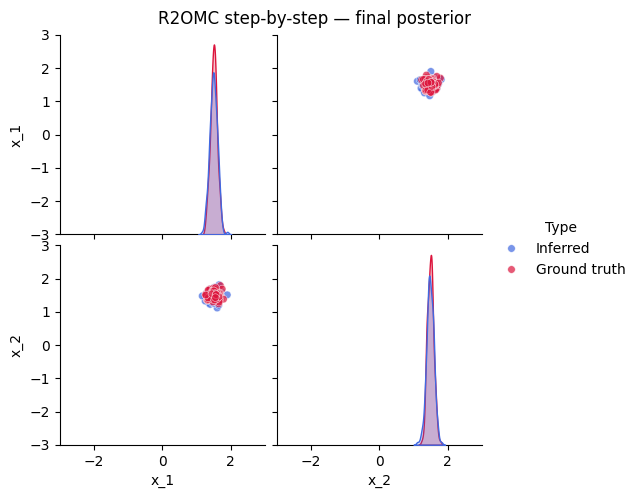

In [23]:
# final plot
method.plot_posterior_samples(
    samples=samples,
    samples_gt=gt_samples,
    limits=[-3, 3],
    title="R2OMC step-by-step — final posterior"
)